# TabPFN: A Foundation Model for Tabular Learning
Tabular data—structured information stored in rows and columns—is at the heart of most real-world machine learning problems, from healthcare records to financial transactions. Over the years, models based on decision trees, such as Random Forest, XGBoost, and CatBoost, have become the default choice for these tasks. Their strength lies in handling mixed data types, capturing complex feature interactions, and delivering strong performance without heavy preprocessing. While deep learning has transformed areas like computer vision and natural language processing, it has historically struggled to consistently outperform these tree-based approaches on tabular datasets.

That long-standing trend is now being questioned. A newer approach, TabPFN, introduces a different way of tackling tabular problems—one that avoids traditional dataset-specific training altogether. Instead of learning from scratch each time, it relies on a pretrained model to make predictions directly, effectively shifting much of the learning process to inference time. In this article, we take a closer look at this idea and put it to the test by comparing TabPFN with established tree-based models like Random Forest and CatBoost on a sample dataset, evaluating their performance in terms of accuracy, training time, and inference speed.

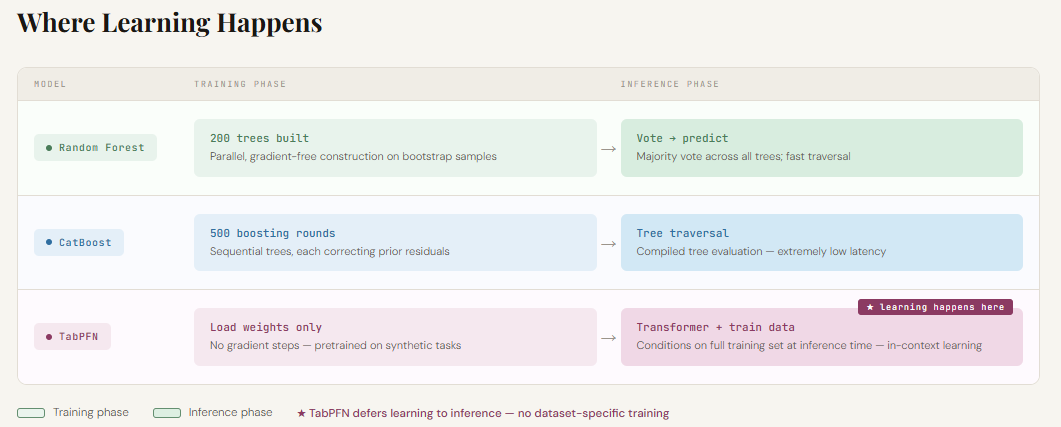

## Setting up the dependencies

In [7]:
# Install required libraries
!pip install tabpfn-client scikit-learn catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 3.3 MB/s eta 0:00:00


In [8]:
import time
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Models
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from tabpfn_client import TabPFNClassifier

To run the model, you require the TabPFN API Key. You can get the same from https://ux.priorlabs.ai/home

In [12]:
import os
from getpass import getpass
os.environ['TABPFN_TOKEN'] = getpass('Enter TABPFN Token: ')

Enter TABPFN Token: ··········


## Creating the dataset
For our experiment, we generate a synthetic binary classification dataset using make_classification from scikit-learn. The dataset contains 5,000 samples and 20 features, out of which 10 are informative (actually contribute to predicting the target) and 5 are redundant (derived from the informative ones). This setup helps simulate a realistic tabular scenario where not all features are equally useful, and some introduce noise or correlation.

We then split the data into training (80%) and testing (20%) sets to evaluate model performance on unseen data. Using a synthetic dataset allows us to have full control over the data characteristics while ensuring a fair and reproducible comparison between TabPFN and traditional tree-based models.


In [3]:
X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Random Forest
We start with a Random Forest classifier as a baseline, using 200 trees. Random Forest is a robust ensemble method that builds multiple decision trees and aggregates their predictions, making it a strong and reliable choice for tabular data without requiring heavy tuning.

After training on the dataset, the model achieves an accuracy of 95.5%, which is a solid performance given the synthetic nature of the data. However, this comes with a training time of 9.56 seconds, reflecting the cost of building hundreds of trees. On the positive side, inference is relatively fast at 0.0627 seconds, since predictions only involve passing data through the already constructed trees. This result serves as a strong baseline to compare against more advanced methods like CatBoost and TabPFN.

In [4]:
rf = RandomForestClassifier(n_estimators=200)

start = time.time()
rf.fit(X_train, y_train)
rf_train_time = time.time() - start

start = time.time()
rf_preds = rf.predict(X_test)
rf_infer_time = time.time() - start

rf_acc = accuracy_score(y_test, rf_preds)

print(f"RandomForest → Acc: {rf_acc:.4f}, Train: {rf_train_time:.2f}s, Infer: {rf_infer_time:.4f}s")

RandomForest → Acc: 0.9550, Train: 9.56s, Infer: 0.0627s


## CatBoost
Next, we train a CatBoost classifier, a gradient boosting model specifically designed for tabular data. It builds trees sequentially, where each new tree corrects the errors of the previous ones. Compared to Random Forest, CatBoost is typically more accurate because of this boosting approach and its ability to model complex patterns more effectively.

On our dataset, CatBoost achieves an accuracy of 96.7%, outperforming Random Forest and demonstrating its strength as a state-of-the-art tree-based method. It also trains slightly faster, taking 8.15 seconds, despite using 500 boosting iterations. One of its biggest advantages is inference speed—predictions are extremely fast at just 0.0119 seconds, making it well-suited for production scenarios where low latency is critical. This makes CatBoost a strong benchmark before comparing against newer approaches like TabPFN.

In [5]:
cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    verbose=0
)

start = time.time()
cat.fit(X_train, y_train)
cat_train_time = time.time() - start

start = time.time()
cat_preds = cat.predict(X_test)
cat_infer_time = time.time() - start

cat_acc = accuracy_score(y_test, cat_preds)

print(f"CatBoost → Acc: {cat_acc:.4f}, Train: {cat_train_time:.2f}s, Infer: {cat_infer_time:.4f}s")

CatBoost → Acc: 0.9670, Train: 8.15s, Infer: 0.0119s


## TabPFN
Finally, we evaluate TabPFN, which takes a fundamentally different approach compared to traditional models. Instead of learning from scratch on the dataset, it leverages a pretrained model and simply conditions on the training data during inference. The .fit() step mainly involves loading the pretrained weights, which is why it is extremely fast.

On our dataset, TabPFN achieves the highest accuracy of 98.8%, outperforming both Random Forest and CatBoost. The fit time is just 0.47 seconds, significantly faster than the tree-based models since no actual training is performed. However, this shift comes with a trade-off—inference takes 2.21 seconds, which is much slower than CatBoost and Random Forest. This is because TabPFN processes both the training and test data together during prediction, effectively performing the “learning” step at inference time.

Overall, TabPFN demonstrates a strong advantage in accuracy and setup speed, while highlighting a different computational trade-off compared to traditional tabular models.


In [15]:
tabpfn = TabPFNClassifier()

start = time.time()
tabpfn.fit(X_train, y_train)  # loads pretrained model
tabpfn_train_time = time.time() - start

start = time.time()
tabpfn_preds = tabpfn.predict(X_test)
tabpfn_infer_time = time.time() - start

tabpfn_acc = accuracy_score(y_test, tabpfn_preds)

print(f"TabPFN → Acc: {tabpfn_acc:.4f}, Fit: {tabpfn_train_time:.2f}s, Infer: {tabpfn_infer_time:.4f}s")

Processing: 100%|██████████| [00:01<00:00]


TabPFN → Acc: 0.9880, Fit: 0.47s, Infer: 2.2164s
